(mmm_funnel_from_yml)=
# Building funnel-aware MMMs from YAML

Most production MMM specs are YAML files: channels, adstock, saturation, and a call to `build_mmm_from_yaml`. That workflow is quick to iterate on and easy to version. **This notebook is about extending it** when your causal story is not a flat list of direct channel effects — without giving up the YAML path.

Three ideas show up together in funnel specs, but they are not equally central here. The sections below separate them so you know what to read here versus elsewhere.

## Funnel-aware structure (background)

Upper-funnel TV and lower-funnel search rarely behave like independent knobs on revenue. A funnel-aware MMM encodes **indirect paths** and **measurement links**, not only direct channel-to-target effects, so spend at one stage can influence the target through intermediate structure. Some topologies introduce **unobserved mediators** — deterministic functions of parent variables, not stochastic latents — together with noisy indicators on observed funnel metrics; others use different node layouts entirely. What you need depends on the causal claims, not on a single funnel template.

We do **not** derive those graphs or fit full models in this notebook. For the causal story, priors, sampling, and ROAS interpretation, see {ref}`mmm_funnel_mueffect` (national topology) and {ref}`mmm_funnel_mueffect_advanced` (geo panel). Treat those notebooks as the reference implementations for design. **Here we walk through two specific topologies** as YAML wiring examples — not a catalogue of every funnel shape.

Each topology is implemented as a **custom `MuEffect` subclass** that `build_mmm_from_yaml` pulls in through `effects:` and `REGISTRY`. The next section describes that wiring loop.

## Custom `MuEffect` classes (wiring, not design)

Funnel structure lives in Python subclasses of `MuEffect` that assemble a subgraph inside the larger MMM. The YAML file names the class; `REGISTRY` resolves it at build time. **Designing** those subgraphs — which nodes exist, which adstock applies where, incrementality links — is the work of the funnel notebooks linked above.

Here we define **notebook-local** classes only to demonstrate the YAML wiring pattern. 

```{tip}
**Where to read first.** {ref}`mmm_build_from_yml_example` for YAML and `build_mmm_from_yaml`; {ref}`mmm_funnel_mueffect` and {ref}`mmm_funnel_mueffect_advanced` for funnel causal graphs and effect-class design.
```

```{important}
`MeasuredMediatorEffect` and `BudgetDualIndicatorEffect` are **notebook-local** names for the two topologies below — not general funnel builders. The YAML specs (`funnel_intro.yml`, `funnel_advanced.yml`) register those classes on `REGISTRY` for this demo only; that is not a supported public API.
```

```{note}
**Reading the causal DAGs.** Grey-filled nodes are observed. Dashed-outline nodes are **unobserved mediators** (node **D**): deterministic combinations of parents, implemented as `pm.Deterministic` in PyMC — not stochastic latents we integrate over. Some YAML kwargs and PyMC names still use `hub` as shorthand for this node (for example `hub_adstock`, `mediator_hub`). Dashed or dotted edges mark measurement or indicator links.
```

## Building models from YAML (focus of this notebook)

If YAML-based MMMs are new to you, start with {ref}`mmm_build_from_yml_example`. That example is the baseline: every spend column under `channel_columns`, standard adstock and saturation, and `build_mmm_from_yaml` on a tabular `X` — a flat causal graph where each channel points straight at the target.

**This notebook keeps the same builder** and shows what changes when the graph is not flat:

- `effects:` entries that reference custom `MuEffect` subclasses
- `extra_vars` for columns that are not channels or controls but must still reach the model graph (for example mediator indicators)

You will see **one naive flat baseline**, then **the two funnel topologies** introduced above, each expressed as YAML beside its causal DAG and PyMC graph. Placeholder `X` / `y` supply the right columns and dimensions; nothing is fit here.

Every example below follows the same loop:

1. **Causal DAG** — the claims the specification makes about the world (hand-drawn for now; see issue #2886)
2. **Effect class** — the `MuEffect` subclass that builds that subgraph (defined beside this notebook, not in the library yet)
3. **YAML** — the configuration file referencing the class through `REGISTRY`
4. **PyMC graph** — the computational graph `build_mmm_from_yaml` produces


First some notebook setup:

In [1]:
import warnings
from pathlib import Path

import graphviz as gr
import numpy as np
import pandas as pd
import pymc.dims as pmd
from IPython.display import Image, Markdown, display
from pydantic import InstanceOf
from pyprojroot import here

from pymc_marketing.mmm import AdstockTransformation, SaturationTransformation
from pymc_marketing.mmm.additive_effect import DataVarMuEffect, IncrementalitySpec
from pymc_marketing.mmm.builders.factories import REGISTRY
from pymc_marketing.mmm.builders.yaml import build_mmm_from_yaml
from pymc_marketing.mmm.media_transformation import MediaTransformation
from pymc_marketing.paths import data_dir

warnings.filterwarnings("ignore")

CONFIG_DIR = data_dir / "config_files"
NOTEBOOK_DIR = here() / "docs" / "source" / "notebooks" / "mmm"

%config InlineBackend.figure_format = "retina"

/Users/benjamv/wt/pymc-marketing/funnel-from-yaml/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


And we'll define some helper functions:

In [2]:
def show_yaml(path: Path) -> None:
    """Print a YAML config so readers can follow along in the notebook."""
    text = path.read_text()
    display(Markdown(f"**`{path.name}`**\n\n```yaml\n{text}```"))


def show_graph(mmm, title: str | None = None) -> None:
    """Display the PyMC graph built from a YAML spec."""
    if title:
        display(Markdown(f"**{title}** — PyMC graph"))
    display(mmm.graphviz())


def _node_attrs(kind: str) -> dict:
    if kind == "observed":
        return {"style": "filled", "fillcolor": "lightgray", "shape": "ellipse"}
    if kind == "latent":
        return {"style": "dashed", "shape": "ellipse"}
    raise ValueError(kind)


def draw_causal_dag(
    nodes: list[tuple[str, str, str]],
    edges: list,
    *,
    title: str | None = None,
    rankdir: str = "LR",
) -> gr.Digraph:
    """Hand-drawn causal DAG. kind is 'observed' or 'latent'."""
    g = gr.Digraph()
    g.attr(rankdir=rankdir)
    if title:
        g.attr(label=title, labelloc="t", fontsize="14")
    for node_id, label, kind in nodes:
        g.node(node_id, label, **_node_attrs(kind))
    for edge in edges:
        if len(edge) == 2:
            g.edge(edge[0], edge[1])
        else:
            g.edge(edge[0], edge[1], **edge[2])
    return g


def show_causal_dag(*args, **kwargs) -> None:
    display(Image(draw_causal_dag(*args, **kwargs).pipe(format="png")))

Finally, we'll create some placeholder data:

In [3]:
n_dates = 10
dates = pd.date_range("2021-01-04", periods=n_dates, freq="W-MON")
X_intro = pd.DataFrame(
    {
        "date": dates,
        "upper_spend": np.ones(n_dates),
        "lower_spend": np.ones(n_dates),
    }
)
y_intro = np.ones(n_dates)

# Funnel columns promoted via `extra_vars` in funnel_intro.yml (not channel_columns).
X_funnel_intro = X_intro.assign(lower_control=np.ones(n_dates))

## Naive baseline — everything is a direct channel

The simplest YAML pattern lists every spend column under `channel_columns`. That is easy to write, but the implied causal graph is flat: each channel points straight at the target with no mediation.

We keep **one** such example here as a contrast point. The funnel sections below need custom effect classes because this baseline cannot express their structure.


### Causal DAG

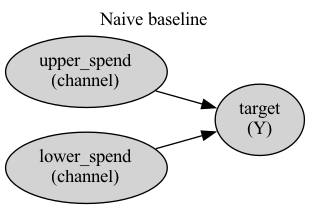

In [4]:
show_causal_dag(
    [
        ("U", "upper_spend\n(channel)", "observed"),
        ("M", "lower_spend\n(channel)", "observed"),
        ("Y", "target\n(Y)", "observed"),
    ],
    [("U", "Y"), ("M", "Y")],
    title="Naive baseline",
)

### YAML

In [5]:
show_yaml(CONFIG_DIR / "funnel_intro_naive_a.yml")

**`funnel_intro_naive_a.yml`**

```yaml
model:
  class: pymc_marketing.mmm.mmm.MMM
  kwargs:
    date_column: date
    target_column: y_obs
    channel_columns: [upper_spend, lower_spend]
    adstock:
      class: pymc_marketing.mmm.GeometricAdstock
      kwargs: {l_max: 8}
    saturation:
      class: pymc_marketing.mmm.LogisticSaturation
      kwargs: {}
    sampler_config:
      nuts_sampler: nutpie

original_scale_vars: [channel_contribution, y]
```

### PyMC graph

**Naive baseline** — PyMC graph

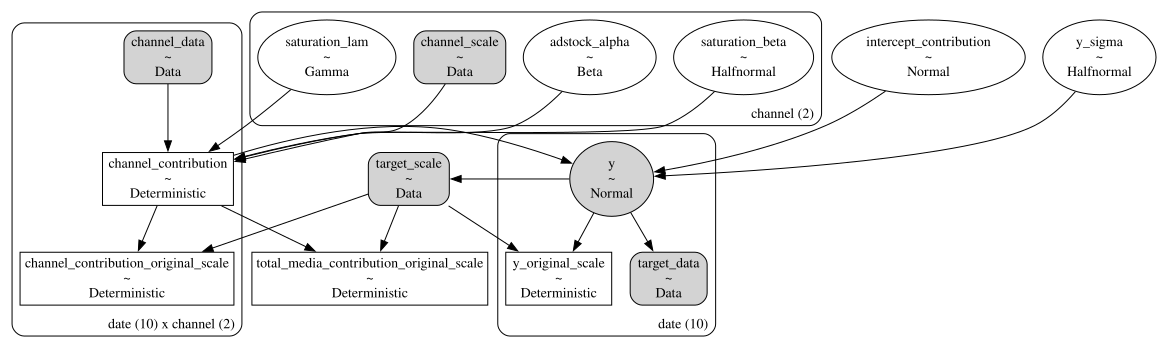

In [6]:
m_naive = build_mmm_from_yaml(
    CONFIG_DIR / "funnel_intro_naive_a.yml", X=X_intro, y=y_intro
)
show_graph(m_naive, "Naive baseline")

## Part 1 — National funnel

{ref}`mmm_funnel_mueffect` encodes upper spend driving an **unobserved demand mediator** (**D** in the DAG below), with observed lower spend as a noisy proxy. The target receives both a direct upper-funnel path (base `MMM`) and an indirect path through that mediator (`MeasuredMediatorEffect`).

This is the first topology where the naive YAML path is not enough. You need **two artifacts written together**: a custom `MuEffect` subclass (the subgraph in Python) and a YAML file whose `effects:` block names that class and passes kwargs that match its fields. The class decides *what* can be configured and *which* columns the subgraph reads; the YAML decides *how* each knob is instantiated (adstock class, `l_max`, prefixes, and so on). Part 2 reuses the same pairing with a different class.

### Causal DAG


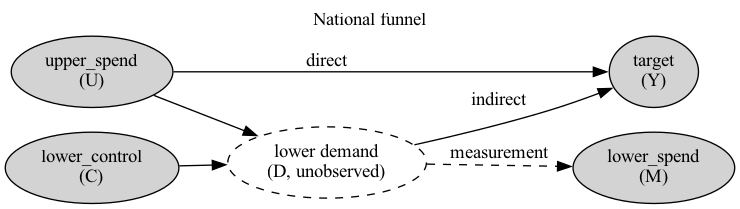

In [7]:
show_causal_dag(
    [
        ("U", "upper_spend\n(U)", "observed"),
        ("C", "lower_control\n(C)", "observed"),
        ("D", "lower demand\n(D, unobserved)", "latent"),
        ("M", "lower_spend\n(M)", "observed"),
        ("Y", "target\n(Y)", "observed"),
    ],
    [
        ("U", "Y", {"label": "direct"}),
        ("U", "D"),
        ("C", "D"),
        ("D", "M", {"label": "measurement", "style": "dashed"}),
        ("D", "Y", {"label": "indirect"}),
    ],
    title="National funnel",
)

### Effect class

`MeasuredMediatorEffect` is the class we need to build this structure: one unobserved mediator (**D**), one measurement (**D → M**), and a mediated contribution into `μ` (**D → Y**). Direct **U → Y** paths stay in base `MMM` via `channel_columns`.

Register the class on `REGISTRY` so `build_mmm_from_yaml` can resolve the name in YAML. Each Pydantic field on the class (`hub_adstock`, `data_vars`, …) is a slot the YAML file must fill (or inherit defaults for). Change the causal graph — add a parent, a measurement, a new column — in Python; change adstock lengths, transformation classes, or variable prefixes in YAML.

The kwargs table maps **YAML keys → subgraph edges**. Names prefixed with `hub_` refer to the unobserved mediator **D** (see the terminology note in the introduction):

| Kwarg | Subgraph edge |
|-------|----------------|
| `hub_adstock`, `hub_saturation` | parent **U → D** (into the mediator) |
| `contribution_adstock`, `contribution_saturation` | **D → μ** |


In [8]:
class MeasuredMediatorEffect(DataVarMuEffect):
    """Unobserved mediator (D) with one measured indicator and a mediated mu contribution."""

    data_vars: list[str] = ["lower_spend", "lower_control"]
    prefix: str = "mediator"
    hub_adstock: InstanceOf[AdstockTransformation]
    hub_saturation: InstanceOf[SaturationTransformation]
    contribution_adstock: InstanceOf[AdstockTransformation]
    contribution_saturation: InstanceOf[SaturationTransformation]

    def to_dict(self) -> dict:
        """Serialize effect configuration."""
        return {
            "prefix": self.prefix,
            "data_vars": list(self.data_vars),
            "hub_adstock": self.hub_adstock.to_dict(),
            "hub_saturation": self.hub_saturation.to_dict(),
            "contribution_adstock": self.contribution_adstock.to_dict(),
            "contribution_saturation": self.contribution_saturation.to_dict(),
        }

    def incrementality_spec(self) -> IncrementalitySpec:
        """Return incrementality settings."""
        return IncrementalitySpec()

    def create_effect(self, mmm):
        """Build the measured-mediator subgraph from the national funnel DAG."""
        model = mmm.model
        parent_into_hub = self.hub_saturation.apply(
            self.hub_adstock.apply(
                mmm.channel_data_scaled.isel(channel=0), core_dim="date"
            ),
            core_dim="date",
        )
        baseline = pmd.HalfNormal(f"{self.prefix}_baseline", sigma=1.0)
        parent_coef = pmd.HalfNormal(f"{self.prefix}_parent_coef", sigma=1.0)
        hub = pmd.Deterministic(
            f"{self.prefix}_hub",
            baseline + parent_coef * model["lower_control"] + parent_into_hub,
        )
        pmd.TruncatedNormal(
            f"{self.prefix}_measurement",
            mu=hub,
            sigma=pmd.HalfNormal(f"{self.prefix}_measurement_sigma", sigma=1.0),
            lower=0.0,
            observed=model["lower_spend"],
        )
        return pmd.Deterministic(
            f"{self.prefix}_effect_contribution",
            self.contribution_saturation.apply(
                self.contribution_adstock.apply(hub, core_dim="date"),
                core_dim="date",
            ),
        )


REGISTRY["MeasuredMediatorEffect"] = MeasuredMediatorEffect

### YAML

`funnel_intro.yml` is the other half of the spec. The `effects:` entry must use the **same class name** as on `REGISTRY` (`MeasuredMediatorEffect`). Every key under `kwargs:` corresponds to a field on that class — unknown keys or missing required fields fail at build time.

`extra_vars` must list every column in the class's `data_vars` (`lower_spend`, `lower_control`). Those columns are not in `channel_columns` or control columns, but the effect still reads them from the xarray Dataset built from `X`.

As things stand, you cannot read this YAML in isolation and recover the causal DAG above. The file names transformations and columns, not claims about **D**, measurement links, or which paths are direct vs mediated. It is the **combination** of `MeasuredMediatorEffect` (which encodes that structure in code) and this YAML configuration (which selects how each subgraph piece is built) that fully specifies the model `build_mmm_from_yaml` assembles.

In [9]:
show_yaml(NOTEBOOK_DIR / "funnel_intro.yml")

**`funnel_intro.yml`**

```yaml
# Requires MeasuredMediatorEffect defined in mmm_funnel_from_yml.ipynb (registered on REGISTRY).
model:
  class: pymc_marketing.mmm.mmm.MMM
  kwargs:
    date_column: date
    target_column: y_obs
    channel_columns: [upper_spend]
    adstock:
      class: pymc_marketing.mmm.GeometricAdstock
      kwargs: {l_max: 8}
    saturation:
      class: pymc_marketing.mmm.LogisticSaturation
      kwargs: {}
    sampler_config:
      nuts_sampler: nutpie

extra_vars: [lower_spend, lower_control]

effects:
  - class: MeasuredMediatorEffect
    kwargs:
      hub_adstock:
        class: pymc_marketing.mmm.GeometricAdstock
        kwargs: {l_max: 8, prefix: adstock_hub}
      hub_saturation:
        class: pymc_marketing.mmm.LogisticSaturation
        kwargs: {prefix: sat_hub}
      contribution_adstock:
        class: pymc_marketing.mmm.GeometricAdstock
        kwargs: {l_max: 8, prefix: adstock_contribution}
      contribution_saturation:
        class: pymc_marketing.mmm.LogisticSaturation
        kwargs: {prefix: sat_contribution}

original_scale_vars: [channel_contribution, mediator_effect_contribution, y]
```

### PyMC graph

**National funnel** — PyMC graph

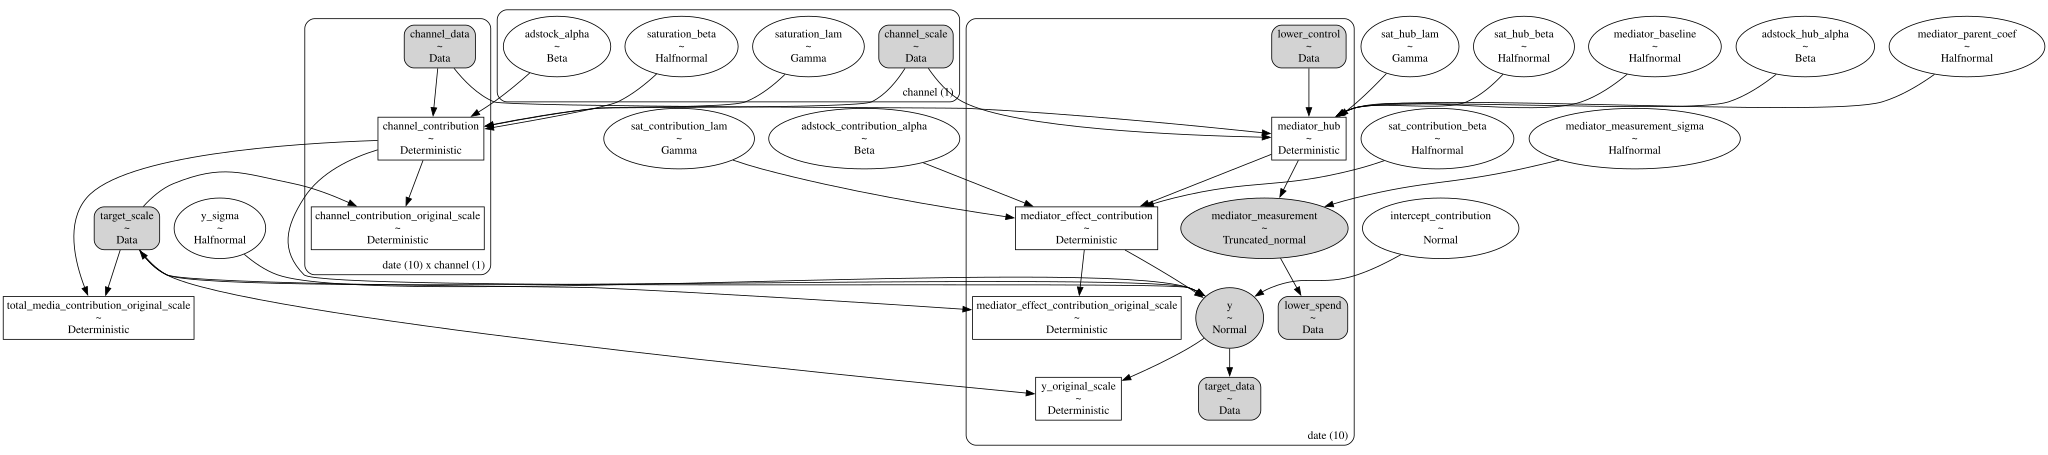

In [10]:
m_funnel = build_mmm_from_yaml(
    NOTEBOOK_DIR / "funnel_intro.yml", X=X_funnel_intro, y=y_intro
)
show_graph(m_funnel, "National funnel")

## Part 2 — Geo panel funnel

The advanced topology from {ref}`mmm_funnel_mueffect_advanced` is **not** the national graph with a `geo` dimension bolted on. It adds category demand, a budget-linked structural spend node, **two** indicator likelihoods, and routes the mediated contribution through that spend node rather than through demand directly.

### Causal DAG


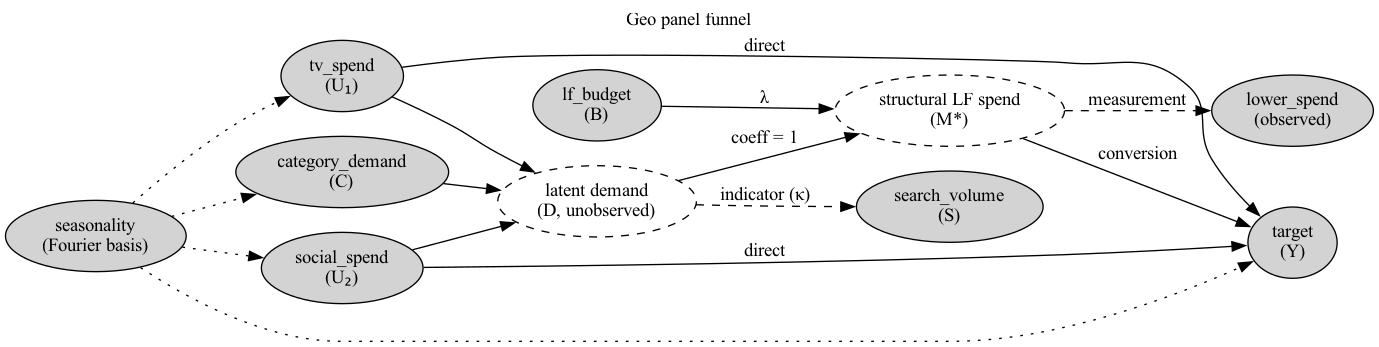

In [11]:
show_causal_dag(
    [
        ("season", "seasonality\n(Fourier basis)", "observed"),
        ("U1", "tv_spend\n(U₁)", "observed"),
        ("U2", "social_spend\n(U₂)", "observed"),
        ("C", "category_demand\n(C)", "observed"),
        ("B", "lf_budget\n(B)", "observed"),
        ("D", "latent demand\n(D, unobserved)", "latent"),
        ("MS", "structural LF spend\n(M*)", "latent"),
        ("M", "lower_spend\n(observed)", "observed"),
        ("S", "search_volume\n(S)", "observed"),
        ("Y", "target\n(Y)", "observed"),
    ],
    [
        ("season", "U1", {"style": "dotted"}),
        ("season", "U2", {"style": "dotted"}),
        ("season", "C", {"style": "dotted"}),
        ("season", "Y", {"style": "dotted"}),
        ("U1", "Y", {"label": "direct"}),
        ("U2", "Y", {"label": "direct"}),
        ("U1", "D"),
        ("U2", "D"),
        ("C", "D"),
        ("D", "MS", {"label": "coeff = 1"}),
        ("B", "MS", {"label": "λ"}),
        ("MS", "M", {"label": "measurement", "style": "dashed"}),
        ("D", "S", {"label": "indicator (κ)", "style": "dashed"}),
        ("MS", "Y", {"label": "conversion"}),
    ],
    title="Geo panel funnel",
)

Placeholder panel data with geo, channel, and lower-funnel columns referenced by `extra_vars`.

In [12]:
geos = ["north", "south", "west"]
rows = [
    {
        "date": date,
        "geo": geo,
        "tv_spend": 1.0,
        "social_spend": 1.0,
        "category_demand": 1.0,
        "t": 0.5,
        "lower_spend": 1.0,
        "search_volume": 1.0,
        "lf_budget": 1.0,
    }
    for date in dates
    for geo in geos
]
X_geo = pd.DataFrame(rows)
y_geo = np.ones(len(X_geo))

### Effect class

`BudgetDualIndicatorEffect` matches this **different** subgraph: the unobserved mediator **D** feeds structural spend through a budget term, lower spend measures that spend node (not **D**), search volume is a second indicator on **D**, and the mediated contribution routes through spend.

As in Part 1, `hub_`-prefixed kwargs target the unobserved mediator **D**:

| Kwarg | Subgraph edge |
|-------|----------------|
| `hub_input_transform` | channel parents **→ D** (into the mediator) |
| `contribution_transform` | structural spend **→ μ** |


In [13]:
class BudgetDualIndicatorEffect(DataVarMuEffect):
    """Unobserved mediator (D), budget-linked structural spend, two indicators, mediated mu contribution."""

    hub_input_transform: InstanceOf[MediaTransformation]
    contribution_transform: InstanceOf[MediaTransformation]

    model_config = {"arbitrary_types_allowed": True}

    def to_dict(self) -> dict:
        """Serialize effect configuration."""
        return {
            "data_vars": self.data_vars,
            "prefix": self.prefix,
            "hub_input_transform": self.hub_input_transform.to_dict(),
            "contribution_transform": self.contribution_transform.to_dict(),
        }

    def incrementality_spec(self) -> IncrementalitySpec:
        """Return incrementality settings."""
        return IncrementalitySpec(
            additional_carryover_lags=self.contribution_transform.adstock.l_max
        )

    def create_effect(self, mmm):
        """Build the budget-linked dual-indicator subgraph from the geo funnel DAG."""
        model = mmm.model
        parents_into_hub = self.hub_input_transform(
            mmm.channel_data_scaled, dim="date"
        ).sum(dim="channel")
        baseline = pmd.HalfNormal(f"{self.prefix}_baseline", sigma=1.0, dims=("geo",))
        parent_coef = pmd.HalfNormal(
            f"{self.prefix}_parent_coef", sigma=1.0, dims=("geo",)
        )
        hub = pmd.Deterministic(
            f"{self.prefix}_hub",
            baseline + parent_coef * model["category_demand"] + parents_into_hub,
        )
        budget_coef = pmd.HalfNormal(
            f"{self.prefix}_budget_coef", sigma=0.5, dims=("geo",)
        )
        spend = pmd.Deterministic(
            f"{self.prefix}_spend",
            hub + budget_coef * model["lf_budget"],
        )
        pmd.TruncatedNormal(
            f"{self.prefix}_spend_measurement",
            mu=spend,
            sigma=pmd.HalfNormal(
                f"{self.prefix}_spend_measurement_sigma", sigma=1.0, dims=("geo",)
            ),
            lower=0.0,
            observed=model["lower_spend"],
        )
        indicator_coef = pmd.HalfNormal(f"{self.prefix}_indicator_coef", sigma=1.0)
        pmd.Normal(
            f"{self.prefix}_hub_indicator",
            mu=indicator_coef * hub,
            sigma=pmd.HalfNormal(
                f"{self.prefix}_hub_indicator_sigma", sigma=1.0, dims=("geo",)
            ),
            observed=model["search_volume"],
        )
        return pmd.Deterministic(
            f"{self.prefix}_effect_contribution",
            self.contribution_transform(spend, dim="date"),
        )


REGISTRY["BudgetDualIndicatorEffect"] = BudgetDualIndicatorEffect

### YAML

Same pattern: `extra_vars` carries lower-funnel and structural columns that `BudgetDualIndicatorEffect` reads from the Dataset.

In [14]:
show_yaml(NOTEBOOK_DIR / "funnel_advanced.yml")

**`funnel_advanced.yml`**

```yaml
# Requires BudgetDualIndicatorEffect defined in mmm_funnel_from_yml.ipynb (registered on REGISTRY).
model:
  class: pymc_marketing.mmm.mmm.MMM
  kwargs:
    date_column: date
    target_column: y
    channel_columns: [tv_spend, social_spend]
    dims: [geo]
    scaling:
      channel: {method: max, dims: []}
      target: {method: max, dims: []}
    adstock:
      class: pymc_marketing.mmm.GeometricAdstock
      kwargs:
        l_max: 8
        priors:
          alpha:
            distribution: Beta
            alpha: 2
            beta: 3
            dims: channel
    saturation:
      class: pymc_marketing.mmm.LogisticSaturation
      kwargs:
        priors:
          lam:
            distribution: Gamma
            mu: 3.0
            sigma: 1.0
            dims: channel
          beta:
            distribution: HalfNormal
            sigma: 1.0
            dims: [geo, channel]
    yearly_seasonality: 2
    model_config:
      intercept:
        distribution: Normal
        mu: 0.2
        sigma: 0.2
        dims: geo
      gamma_fourier:
        distribution: Normal
        mu: 0
        sigma: 0.1
        dims: [geo, fourier_mode]
      likelihood:
        distribution: Normal
        sigma:
          distribution: HalfNormal
          sigma: 0.5
          dims: geo
        dims: [date, geo]
    sampler_config:
      nuts_sampler: nutpie

extra_vars: [lower_spend, search_volume, category_demand, lf_budget]

effects:
  - class: BudgetDualIndicatorEffect
    kwargs:
      data_vars: [lower_spend, search_volume, category_demand, lf_budget]
      prefix: budget_dual
      hub_input_transform:
        class: pymc_marketing.mmm.media_transformation.MediaTransformation
        kwargs:
          adstock_first: true
          dims: [geo, channel]
          adstock:
            class: pymc_marketing.mmm.GeometricAdstock
            kwargs:
              l_max: 8
              prefix: adstock_hub_input
              priors:
                alpha:
                  distribution: Beta
                  alpha: 2
                  beta: 3
                  dims: channel
          saturation:
            class: pymc_marketing.mmm.LogisticSaturation
            kwargs:
              prefix: sat_hub_input
              priors:
                lam:
                  distribution: Gamma
                  mu: 2.0
                  sigma: 1.0
                  dims: channel
                beta:
                  distribution: HalfNormal
                  sigma: 1.0
                  dims: [geo, channel]
      contribution_transform:
        class: pymc_marketing.mmm.media_transformation.MediaTransformation
        kwargs:
          adstock_first: true
          dims: [geo]
          adstock:
            class: pymc_marketing.mmm.GeometricAdstock
            kwargs:
              l_max: 8
              prefix: adstock_contribution
              priors:
                alpha:
                  distribution: Beta
                  alpha: 2
                  beta: 3
                  dims: geo
          saturation:
            class: pymc_marketing.mmm.LogisticSaturation
            kwargs:
              prefix: sat_contribution
              priors:
                lam:
                  distribution: Gamma
                  mu: 1.5
                  sigma: 0.5
                beta:
                  distribution: HalfNormal
                  sigma: 1.0
                  dims: geo

original_scale_vars: [channel_contribution, budget_dual_effect_contribution, y]
```

### PyMC graph

**Geo panel funnel** — PyMC graph

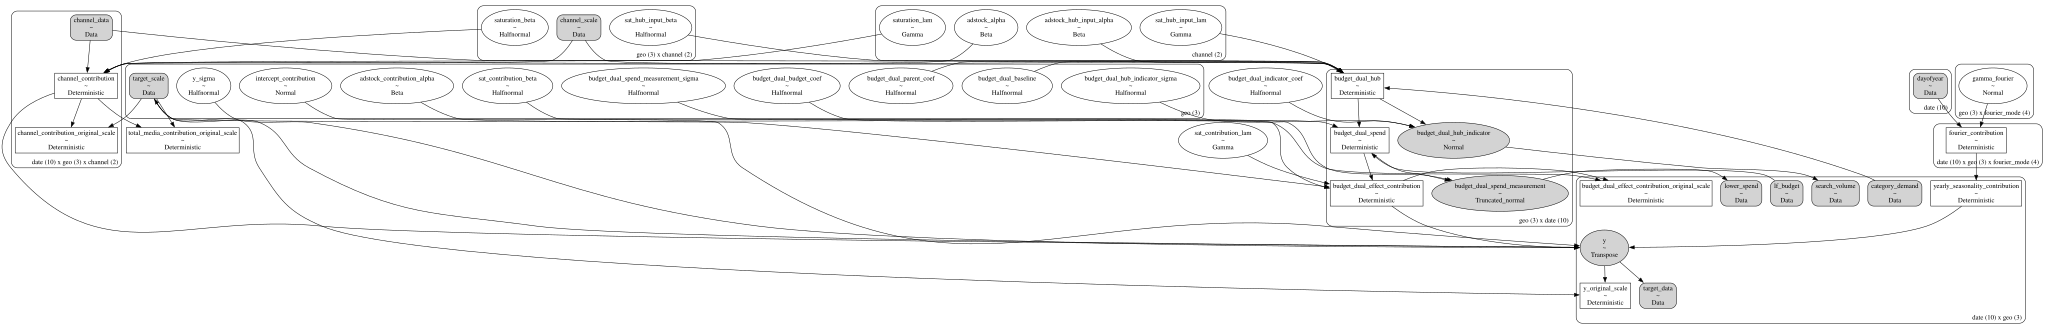

In [15]:
m_geo_funnel = build_mmm_from_yaml(
    NOTEBOOK_DIR / "funnel_advanced.yml", X=X_geo, y=y_geo
)
show_graph(m_geo_funnel, "Geo panel funnel")

## Summary

- A flat YAML spec (`channel_columns` only) implies a direct-effects DAG — useful as a baseline, but it cannot represent mediated funnel structure.
- Funnel specs extend the builder with `effects:` and `extra_vars`. Class names (`MeasuredMediatorEffect`, `BudgetDualIndicatorEffect`) describe **subgraph topology**; “funnel” remains the **use case** in DAGs and narrative.
- The repeatable loop is **causal DAG → effect class → YAML → PyMC graph**. Fitting, priors, and ROAS interpretation stay in {ref}`mmm_funnel_mueffect` and {ref}`mmm_funnel_mueffect_advanced`.

```{tip}
In your own domain: which spend columns are true channels versus noisy proxies for unobserved demand? That distinction is exactly what these effect classes encode — and why one misnamed “FunnelEffect” was never going to cover every DAG.
```


In [16]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor

Last updated: Tue, 18 Aug 2026

Python implementation: CPython
Python version       : 3.12.10
IPython version      : 9.15.0

pymc_marketing: 1.0.0
pytensor      : 3.0.7

IPython       : 9.15.0
graphviz      : 0.21
numpy         : 2.4.6
pandas        : 2.3.3
pydantic      : 2.13.4
pymc          : 6.0.1
pymc_marketing: 1.0.0
pyprojroot    : 0.3.0

Watermark: 2.6.0

